Ноутбук принимает путь к файлу `.docx` и выполняет:

- извлечение и структурную сегментацию документа;
- очистку и нормализацию текста;
- статистическое описание текста;
- эвристическое извлечение персон и топонимов;
- тематическое моделирование;
- сетевой анализ;
- событийную модель;
- экспорт таблиц и рисунков в каталог результатов.




In [ ]:
# Параметры запуска

DOCX_PATH = r"фрегат.docx"   # <-- замените на свой путь к .docx
OUTPUT_DIR = None                      # если None, будет создан каталог рядом с исходным файлом
TARGET_SEGMENT_WORDS = 850             # желаемый размер аналитического сегмента
TOPIC_RANGE = range(4, 9)              # диапазон числа тем для подбора LDA
RANDOM_STATE = 42
MAX_NETWORK_NODES = 25                 # ограничение для визуализаций сетей


In [2]:
from pathlib import Path
import re
import math
import json
import itertools
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from docx import Document
from nltk.stem.snowball import RussianStemmer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

stemmer = RussianStemmer()

MONTHS = {
    'январ': 1, 'феврал': 2, 'март': 3, 'апрел': 4,
    'май': 5, 'мая': 5,
    'июнь': 6, 'июня': 6,
    'июль': 7, 'июля': 7,
    'август': 8,
    'сентябр': 9,
    'октябр': 10,
    'ноябр': 11,
    'декабр': 12
}

RU_STOPWORDS = set("""
и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по
только ее мне было вот от меня еще нет о из ему теперь когда даже ну вдруг ли
если уже или ни быть был него до вас нибудь опять уж вам ведь там потом себя
ничего ей может они тут где есть надо ней для мы тебя их чем была сам чтоб без
будто чего раз тоже себе под будет ж тогда кто этот того потому этого какой
совсем ним здесь этом один почти мой тем чтобы нее сейчас были куда зачем всех
никогда можно при два об другой хоть после над больше тот через эти нас про
всего них какая много разве три эту моя этой перед иногда лучше чуть том нельзя
такой им более всегда конечно всю между
""".split()) | {
    'сво', 'сам', 'наш', 'так', 'эт', 'сказа', 'говор', 'мог', 'мож',
    'нибуд', 'нам', 'нескольк', 'человек', 'самый', 'все', 'весь',
    'один', 'другой', 'котор', 'потому', 'теперь', 'тогда', 'потом',
    'дела', 'очень', 'сегодня', 'вчера', 'стал', 'мо', 'минут',
    'мест', 'видел'
}

roman_re = re.compile(r'^[IVXLCDM]+$')
caps_re = re.compile(r'^[A-ZА-ЯЁ0-9"«»\-\s.,:;!?()]+$')
date_re = re.compile(
    r'(\d{1,2}(\s*\(\s*\d{1,2}\s*\))?\s*(?:январ|феврал|март|апрел|мая|июня|июля|август|сентябр|октябр|ноябр|декабр)|'
    r'с \d|^август|^февраль|^ноябрь|^октябрь|^декабрь|^\d{1,2}-?го\b)',
    re.I
)
sent_split_re = re.compile(r'(?<=[.!?…])\s+(?=[«"A-ZА-ЯЁ0-9])')

LOC_PREPS = r'(?:в|во|из|от|до|к|ко|на|через|между|у|при|под|около|вдоль|мимо)'
PERSON_TITLES = r'(?:барон|адмирал|капитан|мичман|граф|князь|губернатор|штурман|командир|офицер|отец|дед|матрос|гардемарин)'

place_after_prep_re = re.compile(
    rf'\b{LOC_PREPS}\s+([A-ZА-ЯЁ][A-Za-zА-Яа-яЁё-]+(?:\s+[A-ZА-ЯЁ][A-Za-zА-Яа-яЁё-]+){{0,2}})'
)
person_initials_re = re.compile(r'\b[А-ЯЁ]\.\s*[А-ЯЁ]\.\s*[А-ЯЁ][а-яё-]+')
person_title_re = re.compile(rf'\b{PERSON_TITLES}\s+[A-ZА-ЯЁ][A-Za-zА-Яа-яЁё-]+')

EVENT_PATTERNS = {
    'departure': [
        r'\b(отплыл\w*|отправил\w*|снял\w* с якор|вышл\w* в море|тр[оё]нул\w* в путь|двинул\w* в путь)\b'
    ],
    'arrival': [
        r'\b(прибыл\w*|пришл\w*|достиг\w*|вошл\w*|подошл\w*|явил\w* на рейд|вступил\w*)\b'
    ],
    'movement': [
        r'\b(поехал\w*|ехал\w*|плыл\w*|плыли|шл\w*|переехал\w*|переправил\w*|направил\w*|прошл\w*|обогнул\w*)\b'
    ],
    'stay': [
        r'\b(стоял\w*|простоял\w*|остановил\w*|остановк\w*|расположил\w*|бивуак\w*)\b'
    ],
    'meeting': [
        r'\b(встретил\w*|встреч\w*|познаком\w*|принял\w*|разговаривал\w*|беседовал\w*)\b'
    ],
    'weather': [
        r'\b(шторм\w*|бур[яеи]\w*|ветер\w*|туман\w*|дожд\w*|снег\w*|шквал\w*|зной\w*|жар\w*|холод\w*|качк\w*)\b'
    ],
    'illness_danger': [
        r'\b(холер\w*|болезн\w*|ревматизм\w*|лихорадк\w*|утонул\w*|погиб\w*|кораблекруш\w*|опасност\w*|пробоин\w*|ураган\w*)\b'
    ],
    'shipboard_work': [
        r'\b(авральн\w*|парус\w*|снаст\w*|реи\b|якор\w*|погруз\w*|принял\w* порох|свистать|вахт\w*)\b'
    ],
    'observation_reflection': [
        r'\b(увидел\w*|заметил\w*|наблюдал\w*|думал\w*|мне казал\w*|я понял\w*)\b'
    ]
}


In [3]:

def clean_text(s: str) -> str:
    return re.sub(r'\s+', ' ', (s or '').replace('\xa0', ' ')).strip()

def normalize_spaces(text: str) -> str:
    text = text.replace('\xa0', ' ')
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\s*\n\s*', '\n', text)
    return text.strip()

def tokenize_words(text: str):
    return re.findall(r"[A-Za-zА-Яа-яЁё]+(?:-[A-Za-zА-Яа-яЁё]+)?", text)

def normalize_token(tok: str) -> str:
    t = tok.lower().replace('ё', 'е')
    if re.fullmatch(r'[a-z-]+', t):
        return t
    return stemmer.stem(t)

def preprocess_for_topics(text: str):
    out = []
    for tok in tokenize_words(text):
        low = tok.lower().replace('ё', 'е')
        if len(low) < 3 or re.search(r'\d', low):
            continue
        norm = normalize_token(tok)
        if low in RU_STOPWORDS or norm in RU_STOPWORDS or low in ENGLISH_STOP_WORDS:
            continue
        out.append(norm)
    return out

def classify_heading(text: str) -> str:
    t = text.strip()
    if not t:
        return 'empty'
    if t == '***':
        return 'separator'
    if t.lower().startswith('том '):
        return 'volume'
    if t.lower().startswith('конец первого тома'):
        return 'volume_end'
    if roman_re.match(t):
        return 'roman'
    if t.lower().startswith('письмо'):
        return 'letter'
    if t.lower() == 'дневник':
        return 'diary'
    if caps_re.match(t) and len(t) > 3 and not date_re.search(t):
        return 'caps_title'
    if date_re.search(t):
        return 'date_heading'
    return 'other'

def load_docx_paragraphs(path: str) -> pd.DataFrame:
    doc = Document(path)
    rows = []
    for i, p in enumerate(doc.paragraphs):
        rows.append({
            'p_idx': i,
            'style': p.style.name if p.style else '',
            'text': p.text or ''
        })
    return pd.DataFrame(rows)

def build_sections(df: pd.DataFrame) -> pd.DataFrame:
    sections = []
    volume = '1'
    paras = df.to_dict('records')
    for idx, row in enumerate(paras):
        txt = row['text'].strip()
        kind = classify_heading(txt) if row['style'].startswith('Heading') else None
        if kind == 'volume':
            volume = re.sub(r'\D+', '', txt) or volume
        if kind == 'roman':
            titles = []
            j = idx + 1
            while j < len(paras):
                t = paras[j]['text'].strip()
                if not t:
                    j += 1
                    continue
                if paras[j]['style'].startswith('Heading'):
                    k = classify_heading(t)
                    if k in {'caps_title', 'other'} and t != '***':
                        titles.append(t)
                        j += 1
                        continue
                break
            title = " — ".join(titles[:2]) if titles else txt
            sections.append({
                'section_start': row['p_idx'],
                'roman': txt,
                'title': title,
                'volume': volume
            })
    sec_df = pd.DataFrame(sections)
    sec_df['section_end'] = sec_df['section_start'].shift(-1).fillna(df['p_idx'].max() + 1).astype(int) - 1
    sec_df['section_id'] = [f"S{i+1:02d}" for i in range(len(sec_df))]
    return sec_df

def enrich_sections_with_outline(df: pd.DataFrame, sec_df: pd.DataFrame) -> pd.DataFrame:
    sec_df = sec_df.copy()
    outlines = []
    body_starts = []
    for _, s in sec_df.iterrows():
        sub = df[(df['p_idx'] > s['section_start']) & (df['p_idx'] <= s['section_end'])]
        sep = sub[(sub['style'].str.startswith('Heading')) & (sub['text'].str.strip() == '***')]
        if not sep.empty:
            sep_idx = int(sep.iloc[0]['p_idx'])
            before = sub[(sub['p_idx'] < sep_idx) & (sub['style'] == 'Normal')]
            outline = " ".join([clean_text(t) for t in before['text'] if clean_text(t)])
            body_start = sep_idx + 1
        else:
            outline = ""
            body_start = s['section_start'] + 1
        outlines.append(outline)
        body_starts.append(body_start)
    sec_df['outline_text'] = outlines
    sec_df['body_start'] = body_starts
    return sec_df

def assign_sections(df: pd.DataFrame, sec_df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['section_id'] = None
    df['section_title'] = None
    for _, s in sec_df.iterrows():
        mask = (df['p_idx'] >= s['section_start']) & (df['p_idx'] <= s['section_end'])
        df.loc[mask, 'section_id'] = s['section_id']
        df.loc[mask, 'section_title'] = s['title']
    return df

def parse_heading_date(text: str, current_year=None, current_month=None):
    t = text.lower().replace('ё', 'е')
    year = current_year
    month = current_month
    for k, v in MONTHS.items():
        if k in t:
            month = v
            m = re.search(r'(17\d{2}|18\d{2}|19\d{2})', t)
            if m:
                year = int(m.group(1))
            break
    days = [int(x) for x in re.findall(r'(?<!\d)(\d{1,2})(?!\d)', t)]
    return {'raw': text.strip(), 'year': year, 'month': month, 'days': days}

def build_segments(df: pd.DataFrame, sec_df: pd.DataFrame, target_words=850) -> pd.DataFrame:
    skip = set()
    for _, s in sec_df.iterrows():
        sub = df[(df['p_idx'] >= s['section_start']) & (df['p_idx'] < s['body_start'])]
        skip.update(sub['p_idx'].tolist())

    segments = []
    seg_text = []
    seg_meta = None
    current_year = None
    current_month = None

    def flush():
        nonlocal seg_text, seg_meta
        if seg_meta is not None and seg_text:
            text = "\n".join(seg_text).strip()
            wc = len(re.findall(r'[A-Za-zА-Яа-яЁё-]+', text))
            if wc:
                rec = seg_meta.copy()
                rec['text'] = text
                rec['n_words'] = wc
                segments.append(rec)
        seg_text = []
        seg_meta = None

    for _, row in df.iterrows():
        txt = row['text'].strip()
        sec = row['section_id']
        pidx = row['p_idx']
        if sec is None or pidx in skip:
            continue

        if row['style'].startswith('Heading') and txt:
            kind = classify_heading(txt)
            if kind == 'date_heading':
                dt = parse_heading_date(txt, current_year, current_month)
                current_year = dt['year'] if dt['year'] is not None else current_year
                current_month = dt['month'] if dt['month'] is not None else current_month
                flush()
                seg_meta = {
                    'section_id': sec,
                    'section_title': row['section_title'],
                    'episode_title': txt,
                    'date_raw': txt,
                    'year': current_year,
                    'month': current_month
                }
                continue
            elif kind in {'caps_title', 'letter', 'diary', 'other'}:
                flush()
                seg_meta = {
                    'section_id': sec,
                    'section_title': row['section_title'],
                    'episode_title': txt,
                    'date_raw': None,
                    'year': current_year,
                    'month': current_month
                }
                continue
            elif kind == 'separator':
                flush()
                continue

        if not txt:
            continue

        if seg_meta is None:
            seg_meta = {
                'section_id': sec,
                'section_title': row['section_title'],
                'episode_title': None,
                'date_raw': None,
                'year': current_year,
                'month': current_month
            }

        seg_text.append(txt)
        wc = sum(len(re.findall(r'[A-Za-zА-Яа-яЁё-]+', p)) for p in seg_text)
        if wc >= target_words:
            flush()

    flush()
    seg_df = pd.DataFrame(segments)
    seg_df['episode_id'] = [f"E{i+1:03d}" for i in range(len(seg_df))]
    return seg_df

def infer_place_from_title(title: str):
    if not isinstance(title, str) or not title.strip():
        return None
    t = title.strip()
    parts = [p.strip(" .") for p in re.split(r'[.;:]', t) if p.strip()]
    for part in reversed(parts):
        if re.search(r'[А-ЯЁA-Z][а-яёa-z-]+', part) and not re.search(r'\d', part) and part.lower() != 'дневник':
            if not any(k in part.lower() for k in MONTHS):
                return part
    m = re.search(r'ОТ\s+(.+?)\s+ДО\s+(.+)', t)
    if m:
        return m.group(1)
    return None

def canon_entity(entity: str) -> str:
    toks = re.findall(r'[A-Za-zА-Яа-яЁё-]+', entity)
    out = []
    for t in toks:
        low = t.lower().replace('ё', 'е')
        if re.fullmatch(r'[a-z-]+', low):
            out.append(low)
        else:
            out.append(stemmer.stem(low))
    return " ".join(out)

def norm_entity(s: str) -> str:
    s = s.strip(" .,:;!?()[]«»\"'")
    s = re.sub(r'\s+', ' ', s)
    return s

def clean_person_form(form: str) -> str:
    form = norm_entity(form)
    form = re.sub(
        r'^(барон|адмирал|капитан|мичман|граф|князь|губернатор|штурман|командир|офицер|отец)\s+',
        '',
        form,
        flags=re.I
    )
    return form.strip().rstrip('-')

def split_sentences(text: str):
    return [p.strip() for p in sent_split_re.split(text.replace('\n', ' ').strip()) if p.strip()]

def classify_event(sentence: str):
    s = sentence.lower().replace('ё', 'е')
    matched = []
    for etype, pats in EVENT_PATTERNS.items():
        for pat in pats:
            if re.search(pat, s):
                matched.append(etype)
                break
    if not matched:
        return None
    priority = [
        'departure', 'arrival', 'movement', 'stay',
        'meeting', 'weather', 'illness_danger',
        'shipboard_work', 'observation_reflection'
    ]
    for p in priority:
        if p in matched:
            return p
    return matched[0]

def simple_umass_coherence(model, X_bin, top_n=10, eps=1.0):
    scores = []
    topic_word = model.components_
    for topic in topic_word:
        top_idx = topic.argsort()[::-1][:top_n]
        topic_score = 0.0
        pair_count = 0
        for i in range(1, len(top_idx)):
            wi = top_idx[i]
            docs_wi = X_bin[:, wi].toarray().ravel()
            D_wi = docs_wi.sum()
            for j in range(i):
                wj = top_idx[j]
                docs_wj = X_bin[:, wj].toarray().ravel()
                D_wij = np.logical_and(docs_wi > 0, docs_wj > 0).sum()
                topic_score += math.log((D_wij + eps) / (D_wi + eps))
                pair_count += 1
        if pair_count:
            scores.append(topic_score / pair_count)
    return float(np.mean(scores)) if scores else float('nan')

def build_canonical_map(counter: Counter, min_count=2):
    bykey = defaultdict(Counter)
    for surf, count in counter.items():
        if count < min_count:
            continue
        key = canon_entity(surf)
        bykey[key][surf] += count

    cmap = {}
    rows = []
    for key, surfs in bykey.items():
        label = surfs.most_common(1)[0][0]
        total = sum(surfs.values())
        cmap[key] = label
        rows.append({'key': key, 'label': label, 'count': total, 'variants': dict(surfs)})
    lex_df = pd.DataFrame(rows).sort_values('count', ascending=False)
    return cmap, lex_df


In [4]:

docx_path = Path(DOCX_PATH)
if not docx_path.exists():
    raise FileNotFoundError(f"Файл не найден: {docx_path}")

if OUTPUT_DIR is None:
    output_dir = docx_path.parent / f"{docx_path.stem}_analysis_outputs"
else:
    output_dir = Path(OUTPUT_DIR)

output_dir.mkdir(parents=True, exist_ok=True)

paragraphs_df = load_docx_paragraphs(str(docx_path))
sections_df = build_sections(paragraphs_df)
sections_df = enrich_sections_with_outline(paragraphs_df, sections_df)
paragraphs_df = assign_sections(paragraphs_df, sections_df)
segments_df = build_segments(paragraphs_df, sections_df, target_words=TARGET_SEGMENT_WORDS)

sections_df[['route_from', 'route_to']] = sections_df['title'].apply(
    lambda t: pd.Series(re.search(r'ОТ\s+(.+?)\s+ДО\s+(.+)', t).groups())
    if isinstance(t, str) and re.search(r'ОТ\s+(.+?)\s+ДО\s+(.+)', t)
    else pd.Series([None, None])
)

display(Markdown("## 1. Структура документа"))
display(sections_df[['section_id', 'volume', 'roman', 'title', 'body_start', 'section_end']].head(20))
display(Markdown(f"Выделено **{len(sections_df)}** крупных разделов и **{len(segments_df)}** аналитических сегментов."))


## 1. Структура документа

,section_id,volume,roman,title,body_start,section_end
0,S01,1,I,ОТ КРОНШТАДТА ДО МЫСА ЛИЗАРДА,15,242
1,S02,1,II,АТЛАНТИЧЕСКИЙ ОКЕАН И ОСТРОВ МАДЕРА,244,383
2,S03,1,III,ПЛАВАНИЕ В АТЛАНТИЧЕСКИХ ТРОПИКАХ,395,489
3,S04,1,IV,НА МЫСЕ ДОБРОЙ НАДЕЖДЫ,693,954
4,S05,1,V,ОТ МЫСА ДОБРОЙ НАДЕЖДЫ ДО ОСТРОВА ЯВЫ,964,1050
5,S06,1,VI,СИНГАПУР,1052,1199
6,S07,1,VII,ГОН-КОНГ,1209,1244
7,S08,1,VIII,ОСТРОВА БОНИН-СИМА,1246,1357
8,S09,2,I,РУССКИЕ В ЯПОНИИ — в конце 1853 и в начале 185...,1359,1812
9,S10,2,II,ШАНХАЙ,1814,2009


Выделено **24** крупных разделов и **290** аналитических сегментов.

In [5]:

# Построение эвристических словарей персон и мест

person_forms = []
for text in segments_df['text']:
    person_forms.extend([clean_person_form(m.group(0)) for m in person_initials_re.finditer(text)])
    person_forms.extend([clean_person_form(m.group(0)) for m in person_title_re.finditer(text)])
person_counts = Counter([p for p in person_forms if p])

place_surface_counts = Counter()
for text in segments_df['text']:
    for m in place_after_prep_re.finditer(text):
        cand = norm_entity(m.group(1))
        if len(cand) >= 3:
            place_surface_counts[cand] += 1

for title in list(segments_df['episode_title'].dropna()) + list(sections_df['title'].dropna()):
    hp = infer_place_from_title(title)
    if hp:
        place_surface_counts[norm_entity(hp)] += 2

person_map, person_lex_df = build_canonical_map(person_counts, min_count=2)
place_map, place_lex_df = build_canonical_map(place_surface_counts, min_count=3)

def extract_persons(text: str):
    found = []
    for m in person_initials_re.finditer(text):
        found.append(clean_person_form(m.group(0)))
    for m in person_title_re.finditer(text):
        found.append(clean_person_form(m.group(0)))
    for label in person_lex_df['label'].tolist():
        if len(label.split()) == 1 and re.search(rf'\b{re.escape(label)}[а-яё-]*\b', text, flags=re.I):
            found.append(label)
    canon = []
    for f in found:
        key = canon_entity(f)
        canon.append(person_map.get(key, f))
    return sorted(set([c for c in canon if c]))

def extract_places(text: str, episode_title=None, section_title=None):
    found = []
    for m in place_after_prep_re.finditer(text):
        cand = norm_entity(m.group(1))
        found.append(place_map.get(canon_entity(cand), cand))
    for title in [episode_title, section_title]:
        hp = infer_place_from_title(title) if title else None
        if hp:
            found.append(place_map.get(canon_entity(hp), hp))
    bad = {'Русские', 'Дневник', 'Плавание', 'Обратный', 'Путь', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX'}
    return sorted(set([x for x in found if x and x not in bad and len(x) > 2]))

def place_counts(text: str, episode_title=None, section_title=None):
    c = Counter()
    for m in place_after_prep_re.finditer(text):
        cand = norm_entity(m.group(1))
        c[place_map.get(canon_entity(cand), cand)] += 1
    for title in [episode_title, section_title]:
        hp = infer_place_from_title(title) if title else None
        if hp:
            c[place_map.get(canon_entity(hp), hp)] += 2
    return c

entity_rows = []
for _, r in segments_df.iterrows():
    persons = extract_persons(r['text'])
    places = extract_places(r['text'], r['episode_title'], r['section_title'])
    pcounts = place_counts(r['text'], r['episode_title'], r['section_title'])
    entity_rows.append({
        'episode_id': r['episode_id'],
        'persons': persons,
        'places': places,
        'n_persons': len(persons),
        'n_places': len(places),
        'primary_place': pcounts.most_common(1)[0][0] if pcounts else None
    })

entities_df = pd.DataFrame(entity_rows)
segments_df = segments_df.merge(entities_df, on='episode_id', how='left')

display(Markdown("## 2. Эвристически выделенные сущности"))
display(person_lex_df.head(15))
display(place_lex_df.head(20))


## 2. Эвристически выделенные сущности

,key,label,count,variants
2,аввакум,Аввакум,24,{'Аввакум': 24}
6,крюднер,Крюднер,19,{'Крюднер': 19}
11,к н посьет,К. Н. Посьет,19,"{'К. Н. Посьет': 13, 'К. Н. Посьету': 4, 'К. Н..."
17,оболенск,Оболенский,10,{'Оболенский': 10}
9,о а гошкевич,О. А. Гошкевич,9,"{'О. А. Гошкевич': 7, 'О. А. Гошкевича': 2}"
3,п а тихмен,П. А. Тихменев,7,{'П. А. Тихменев': 7}
0,шлипенб,Шлипенбах,5,{'Шлипенбах': 5}
8,к и лос,К. И. Лосев,5,{'К. И. Лосев': 5}
1,в а корсак,В. А. Корсаков,5,{'В. А. Корсаков': 5}
14,и в фуругельм,И. В. Фуругельм,4,{'И. В. Фуругельм': 4}


,key,label,count,variants
41,ед,Едо,79,{'Едо': 79}
0,англ,Англии,65,"{'Англии': 50, 'Англию': 15}"
3,кита,Китае,63,"{'Китае': 41, 'Китай': 22}"
11,япон,Японии,62,"{'Японию': 20, 'Японии': 42}"
31,манил,Маниле,43,"{'Манилу': 9, 'Манилы': 6, 'Маниле': 24, 'МАНИ..."
40,нагасак,Нагасаки,39,{'Нагасаки': 39}
9,европ,Европы,39,"{'Европы': 15, 'Европу': 10, 'Европе': 14}"
59,якутск,Якутска,38,"{'Якутску': 4, 'Якутска': 18, 'Якутске': 8, 'Я..."
13,петербург,Петербурге,37,"{'Петербурга': 14, 'Петербурге': 17, 'Петербур..."
48,шанха,Шанхай,35,"{'Шанхай': 19, 'Шанхае': 16}"


## 3. Статистика текста

,Показатель,Значение
0,Файл,фрегат.docx
1,Количество разделов,24
2,Количество аналитических сегментов,290
3,Количество непустых абзацев,3085
4,Количество предложений,14140
5,Количество словоформ,226037
6,Количество нормализованных токенов,127638
7,Средняя длина сегмента (слов),779.39
8,Средняя длина абзаца (слов),78.66
9,Сегментов с персонажами,123


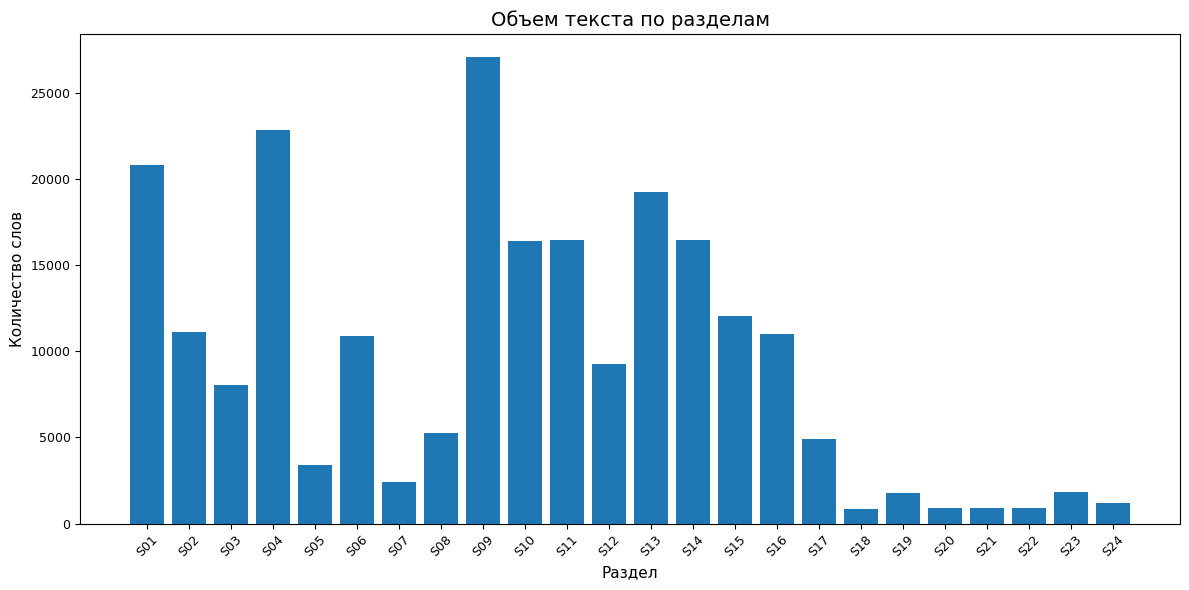

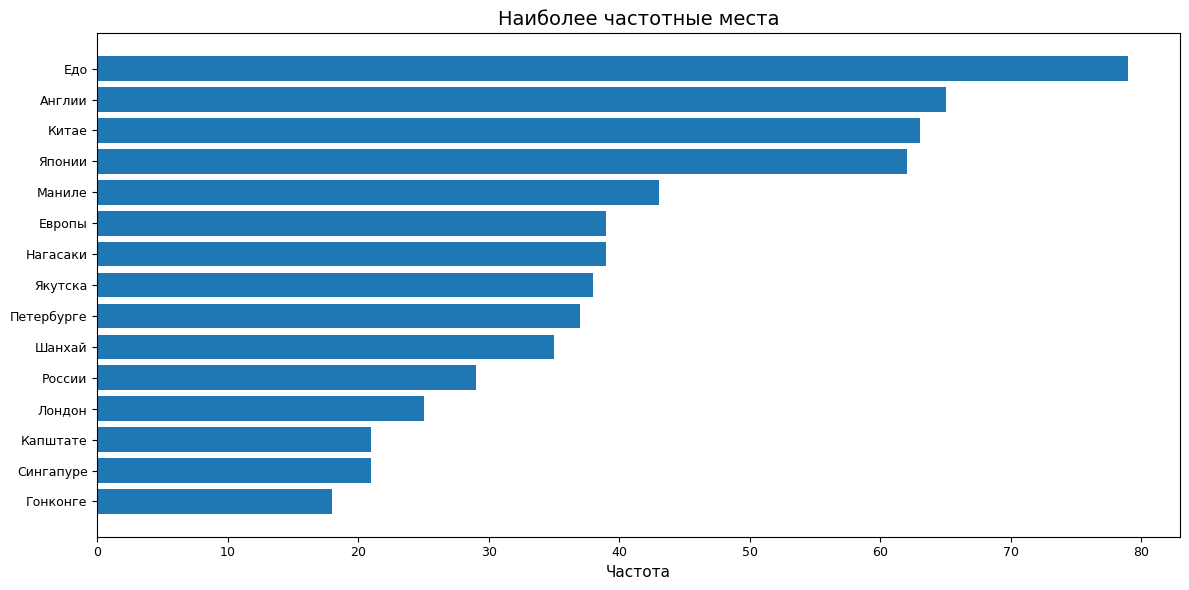

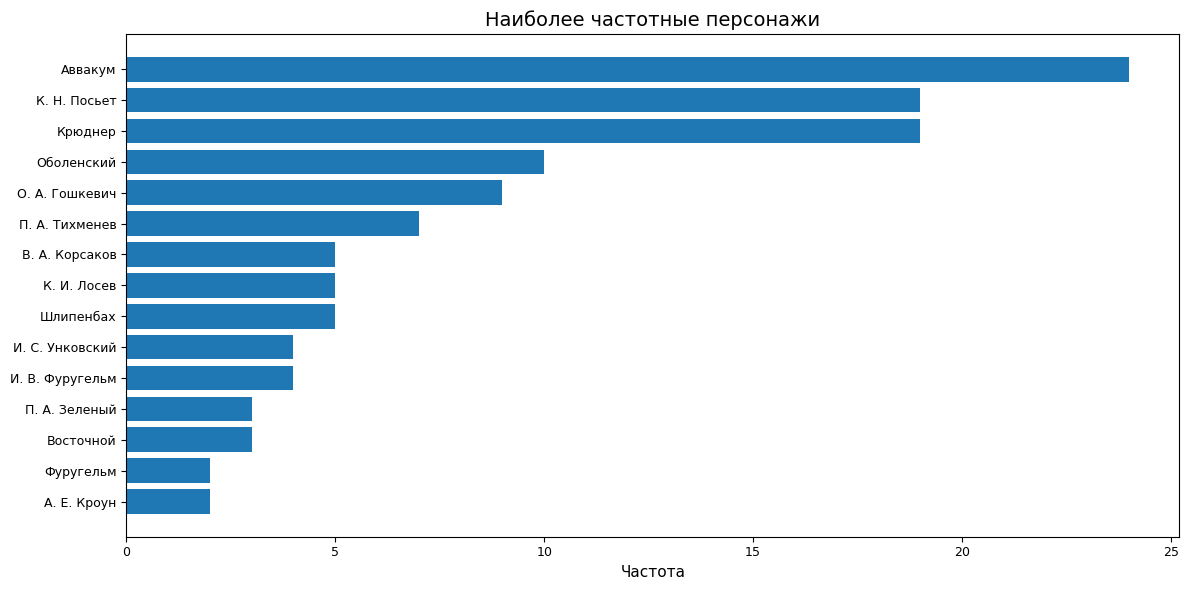

In [6]:

# Общая статистика текста

paragraphs_nonempty = paragraphs_df[paragraphs_df['text'].str.strip().astype(bool)].copy()
paragraphs_nonempty['n_words'] = paragraphs_nonempty['text'].apply(lambda x: len(tokenize_words(x)))

sent_count = sum(len(split_sentences(t)) for t in segments_df['text'])
token_count = sum(len(tokenize_words(t)) for t in segments_df['text'])
lemma_like_count = sum(len(preprocess_for_topics(t)) for t in segments_df['text'])

stats_df = pd.DataFrame([
    ('Файл', docx_path.name),
    ('Количество разделов', len(sections_df)),
    ('Количество аналитических сегментов', len(segments_df)),
    ('Количество непустых абзацев', len(paragraphs_nonempty)),
    ('Количество предложений', sent_count),
    ('Количество словоформ', token_count),
    ('Количество нормализованных токенов', lemma_like_count),
    ('Средняя длина сегмента (слов)', round(segments_df['n_words'].mean(), 2)),
    ('Средняя длина абзаца (слов)', round(paragraphs_nonempty['n_words'].mean(), 2)),
    ('Сегментов с персонажами', int((segments_df['n_persons'] > 0).sum())),
    ('Сегментов с топонимами', int((segments_df['n_places'] > 0).sum())),
    ('Уникальных персон', len(person_lex_df)),
    ('Уникальных мест', len(place_lex_df)),
], columns=['Показатель', 'Значение'])

display(Markdown("## 3. Статистика текста"))
display(stats_df)

section_lengths = segments_df.groupby('section_id')['n_words'].sum().reset_index()
section_lengths = section_lengths.merge(sections_df[['section_id', 'title']], on='section_id', how='left')

plt.figure()
plt.bar(section_lengths['section_id'], section_lengths['n_words'])
plt.title("Объем текста по разделам")
plt.xlabel("Раздел")
plt.ylabel("Количество слов")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / "section_lengths.png", dpi=160)
plt.show()

top_places = place_lex_df.head(15).sort_values('count')
plt.figure()
plt.barh(top_places['label'], top_places['count'])
plt.title("Наиболее частотные места")
plt.xlabel("Частота")
plt.tight_layout()
plt.savefig(output_dir / "top_places.png", dpi=160)
plt.show()

top_persons = person_lex_df.head(15).sort_values('count')
plt.figure()
plt.barh(top_persons['label'], top_persons['count'])
plt.title("Наиболее частотные персонажи")
plt.xlabel("Частота")
plt.tight_layout()
plt.savefig(output_dir / "top_persons.png", dpi=160)
plt.show()


## 4. Тематическое моделирование

,k,coherence,perplexity
0,4,-0.677510,3382.759994
1,5,-0.899353,3391.245918
2,6,-0.959242,3442.135193
3,7,-0.761381,3498.796327
4,8,-0.828122,3565.373234


Выбрано число тем: **4**

,topic_id,top_words,weight_sum
0,0,"мор, берег, неб, кают, нибуд, вод, матрос, фре...",33.069066
1,1,"берег, гор, лошад, дом, дорог, зелен, дерев, в...",122.048266
2,2,"японц, губернатор, адмира, японск, ед, берег, ...",79.081734
3,3,"спрос, нибуд, больш, дом, по, отвеча, лиц, обе...",55.800934


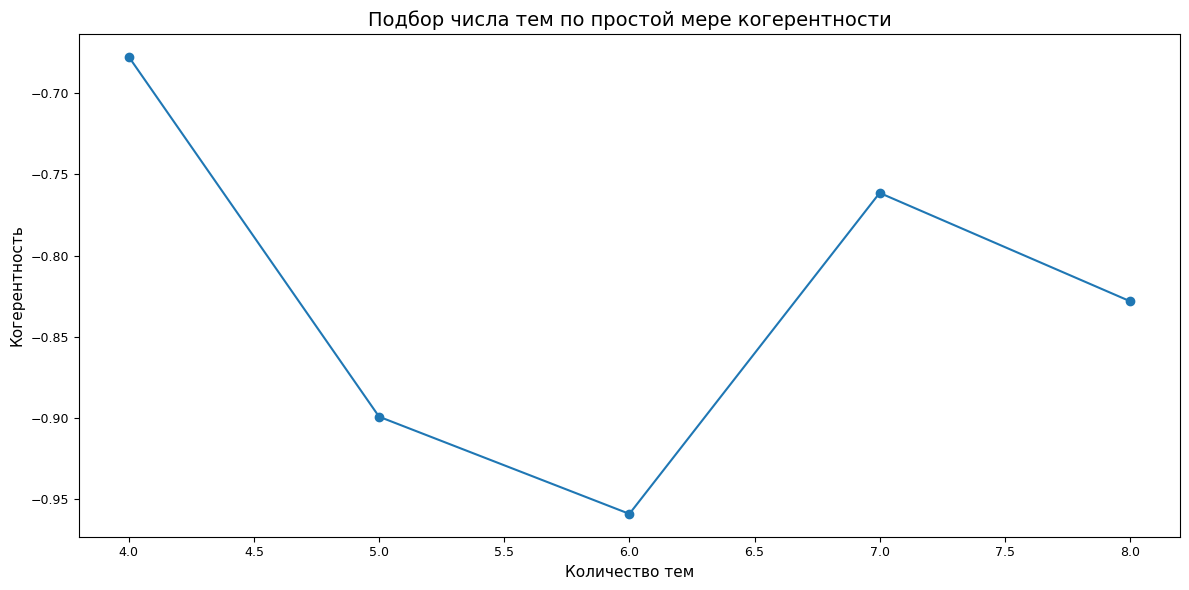

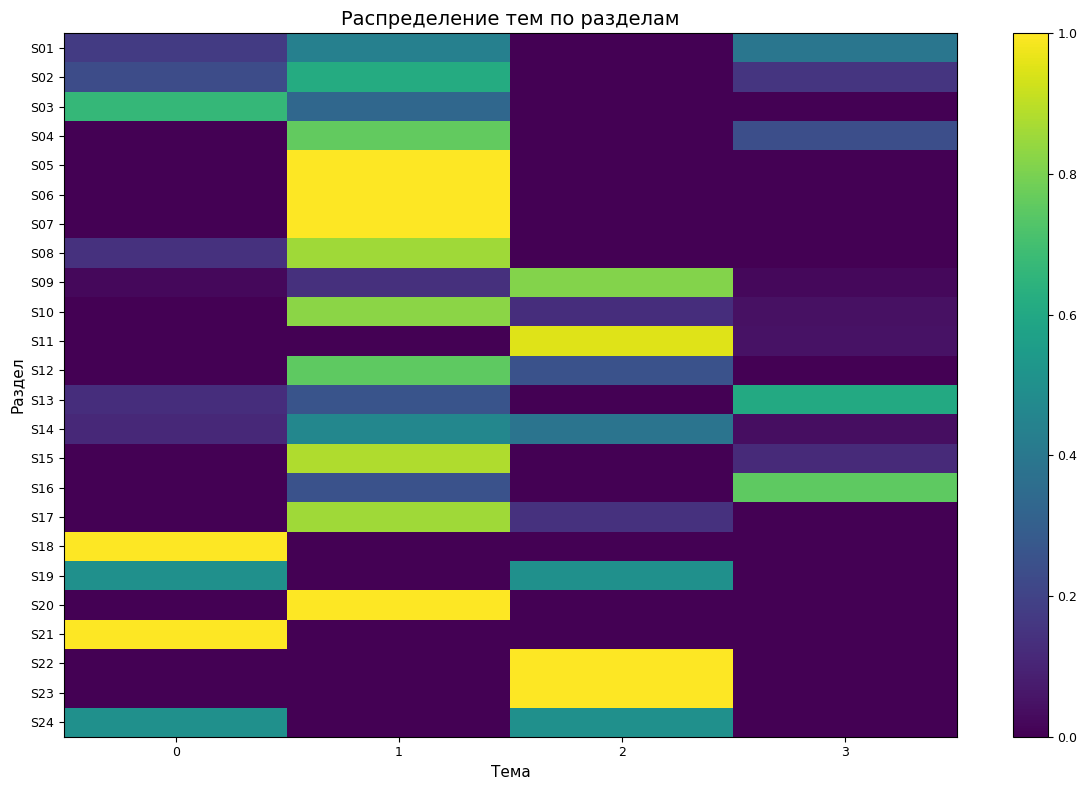

,topic_id,episode_id,section_id,episode_title,primary_place,topic_weight,text_fragment
0,0,E045,S03,None,None,0.9984,"Изумленный глаз смотрит вокруг, не увидит ли р..."
1,0,E043,S03,None,Англии,0.9983,Рассчитывали на дующие около того времени вест...
2,0,E044,S03,None,None,0.9983,Отстаньте от меня: вы все в беду меня вводите!...
3,1,E050,S04,None,Капштате,0.9987,"Стелленбош славится в колонии своею зеленью, ф..."
4,1,E158,S10,None,Фогу,0.9985,"На другой день, вставши и пообедавши, я пошел,..."
5,1,E199,S13,Февраль 1854 г.,МАНИЛА — От Лю-чу до Манилы,0.9985,"Лишь только встали мы утром 16 февраля, я выше..."
6,2,E114,S09,None,Едо,0.9984,Давно ли сарказмом отвечали японцы на совет го...
7,2,E160,S10,None,Китае,0.9984,Причины возвышения Шанхая заключаются в выгодн...
8,2,E106,S09,None,Китае,0.9983,Сравните японское воспитание с китайским: оно ...
9,3,E209,S13,None,МАНИЛА — От Лю-чу до Манилы,0.9984,Минуты через три вдруг дверь начала потихоньку...


In [7]:

# Тематическое моделирование (LDA)

segments_df['prep_text'] = segments_df['text'].apply(lambda t: " ".join(preprocess_for_topics(t)))

vectorizer = CountVectorizer(max_df=0.75, min_df=3)
X = vectorizer.fit_transform(segments_df['prep_text'])
X_bin = (X > 0).astype(int)

topic_scores = []
for k in TOPIC_RANGE:
    lda_tmp = LatentDirichletAllocation(
        n_components=k,
        random_state=RANDOM_STATE,
        learning_method='batch',
        max_iter=20
    )
    _ = lda_tmp.fit_transform(X)
    topic_scores.append({
        'k': k,
        'coherence': simple_umass_coherence(lda_tmp, X_bin),
        'perplexity': float(lda_tmp.perplexity(X))
    })

topic_scores_df = pd.DataFrame(topic_scores)
best_k = int(topic_scores_df.sort_values(['coherence', 'perplexity'], ascending=[False, True]).iloc[0]['k'])

lda_model = LatentDirichletAllocation(
    n_components=best_k,
    random_state=RANDOM_STATE,
    learning_method='batch',
    max_iter=20
)
doc_topic = lda_model.fit_transform(X)
feature_names = np.array(vectorizer.get_feature_names_out())

topic_rows = []
for i, comp in enumerate(lda_model.components_):
    top_idx = np.argsort(comp)[::-1][:12]
    topic_rows.append({
        'topic_id': i,
        'top_words': ", ".join(feature_names[top_idx]),
        'weight_sum': float(doc_topic[:, i].sum())
    })

topics_df = pd.DataFrame(topic_rows).sort_values('topic_id')
segments_df['topic_id'] = doc_topic.argmax(axis=1)
segments_df['topic_weight'] = doc_topic.max(axis=1)

display(Markdown("## 4. Тематическое моделирование"))
display(topic_scores_df)
display(Markdown(f"Выбрано число тем: **{best_k}**"))
display(topics_df)

plt.figure()
plt.plot(topic_scores_df['k'], topic_scores_df['coherence'], marker='o')
plt.title("Подбор числа тем по простой мере когерентности")
plt.xlabel("Количество тем")
plt.ylabel("Когерентность")
plt.tight_layout()
plt.savefig(output_dir / "topic_selection.png", dpi=160)
plt.show()

topic_share_by_section = pd.crosstab(segments_df['section_id'], segments_df['topic_id'], normalize='index')
plt.figure(figsize=(12, 8))
plt.imshow(topic_share_by_section.values, aspect='auto')
plt.title("Распределение тем по разделам")
plt.xlabel("Тема")
plt.ylabel("Раздел")
plt.xticks(range(topic_share_by_section.shape[1]), topic_share_by_section.columns)
plt.yticks(range(topic_share_by_section.shape[0]), topic_share_by_section.index)
plt.colorbar()
plt.tight_layout()
plt.savefig(output_dir / "topic_by_section_heatmap.png", dpi=160)
plt.show()

rep_segments = []
for topic_id in sorted(segments_df['topic_id'].unique()):
    subset = segments_df[segments_df['topic_id'] == topic_id].sort_values('topic_weight', ascending=False).head(3)
    for _, r in subset.iterrows():
        rep_segments.append({
            'topic_id': topic_id,
            'episode_id': r['episode_id'],
            'section_id': r['section_id'],
            'episode_title': r['episode_title'],
            'primary_place': r['primary_place'],
            'topic_weight': round(float(r['topic_weight']), 4),
            'text_fragment': r['text'][:350].replace('\n', ' ')
        })

topic_examples_df = pd.DataFrame(rep_segments)
display(topic_examples_df.head(20))


## 5. Сетевой анализ

,source,target,weight
18,Аввакум,К. Н. Посьет,5
7,К. И. Лосев,Лосев,5
39,И. В. Фуругельм,Фуругельм,4
3,Аввакум,П. А. Тихменев,4
32,Аввакум,В. А. Корсаков,3
15,К. Н. Посьет,Крюднер,2
79,В. А. Римский,Восточной,2
80,В. А. Римский,Н. Н. Муравьев,2
59,И. С. Унковский,О. А. Гошкевич,2
41,Аввакум,Крюднер,2


,source,target,weight
129,МАНИЛА — От Лю-чу до Манилы,Маниле,5
128,Маниле,МАНИЛА — От Лю-чу до Манилы,5
66,Нагасаки,Едо,4
5,Кронштадта,Англии,3
6,Англии,Кронштадта,3
137,Японии,Маниле,2
81,Едо,Нагасаки,2
64,Едо,Японии,2
70,Китае,Едо,2
25,Африке,Капштате,2


,person,place,weight
416,Крюднер,Маниле,10
51,Аввакум,Китае,9
0,Крюднер,Англии,7
453,Аввакум,Маниле,7
50,Аввакум,Англии,7
282,Аввакум,Японии,7
264,Аввакум,Шанхай,7
415,Крюднер,МАНИЛА — От Лю-чу до Манилы,7
225,К. Н. Посьет,Едо,6
172,Восточной,Китае,6


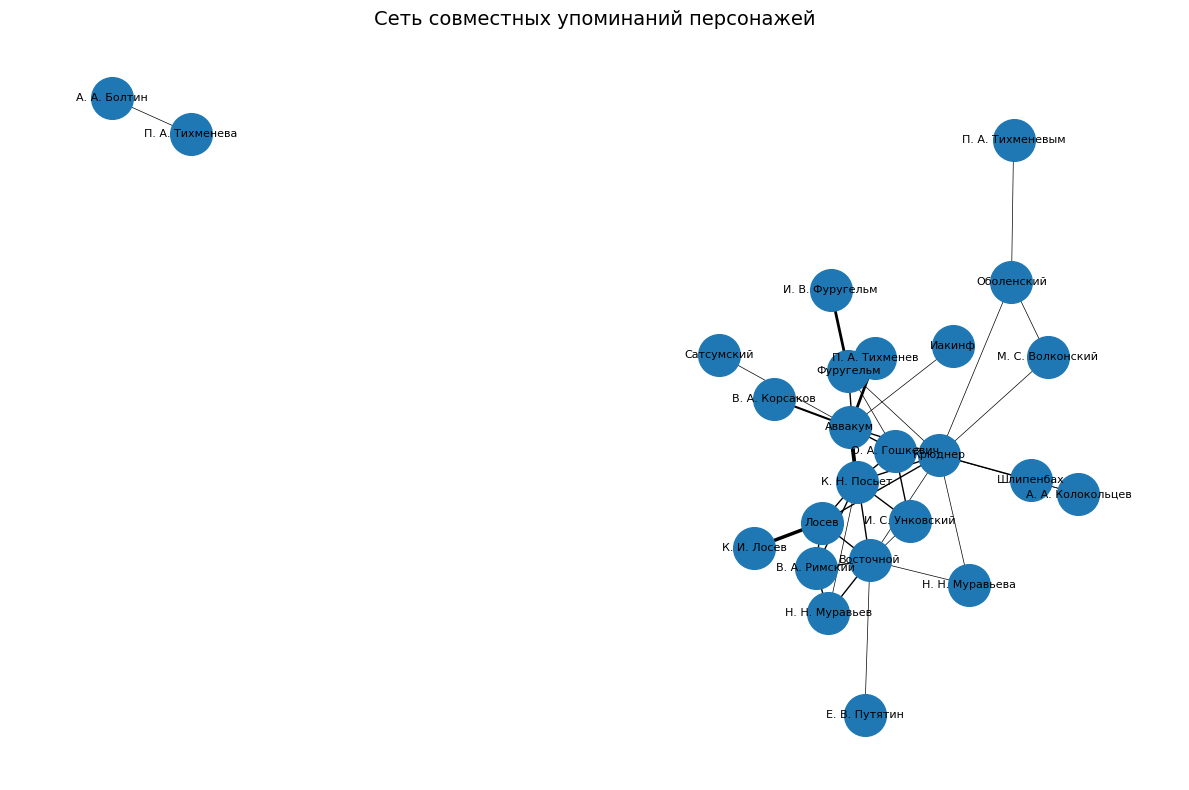

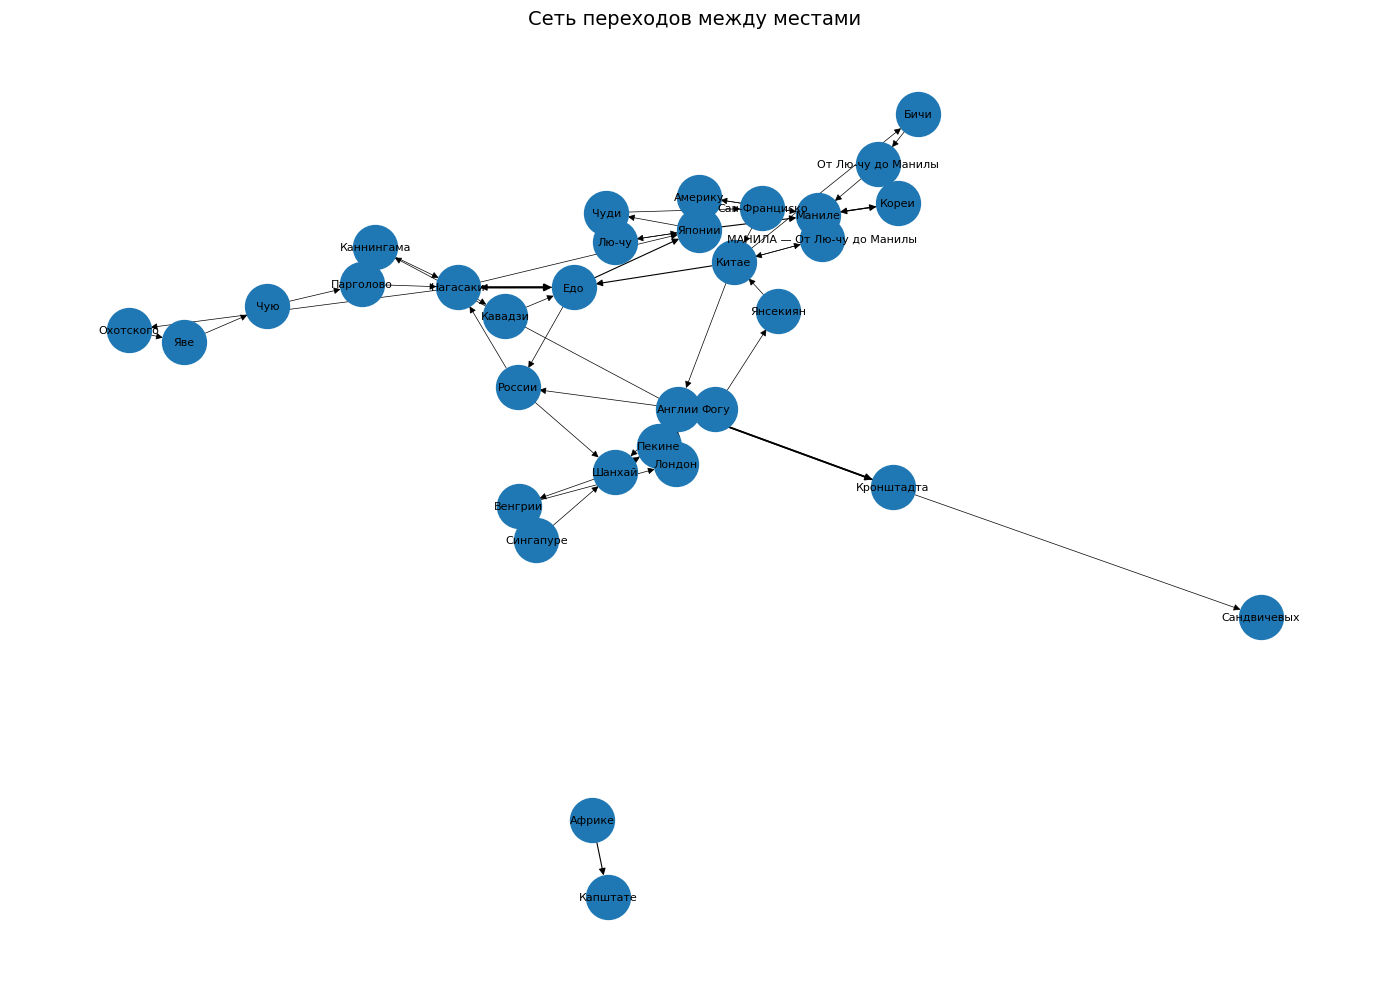

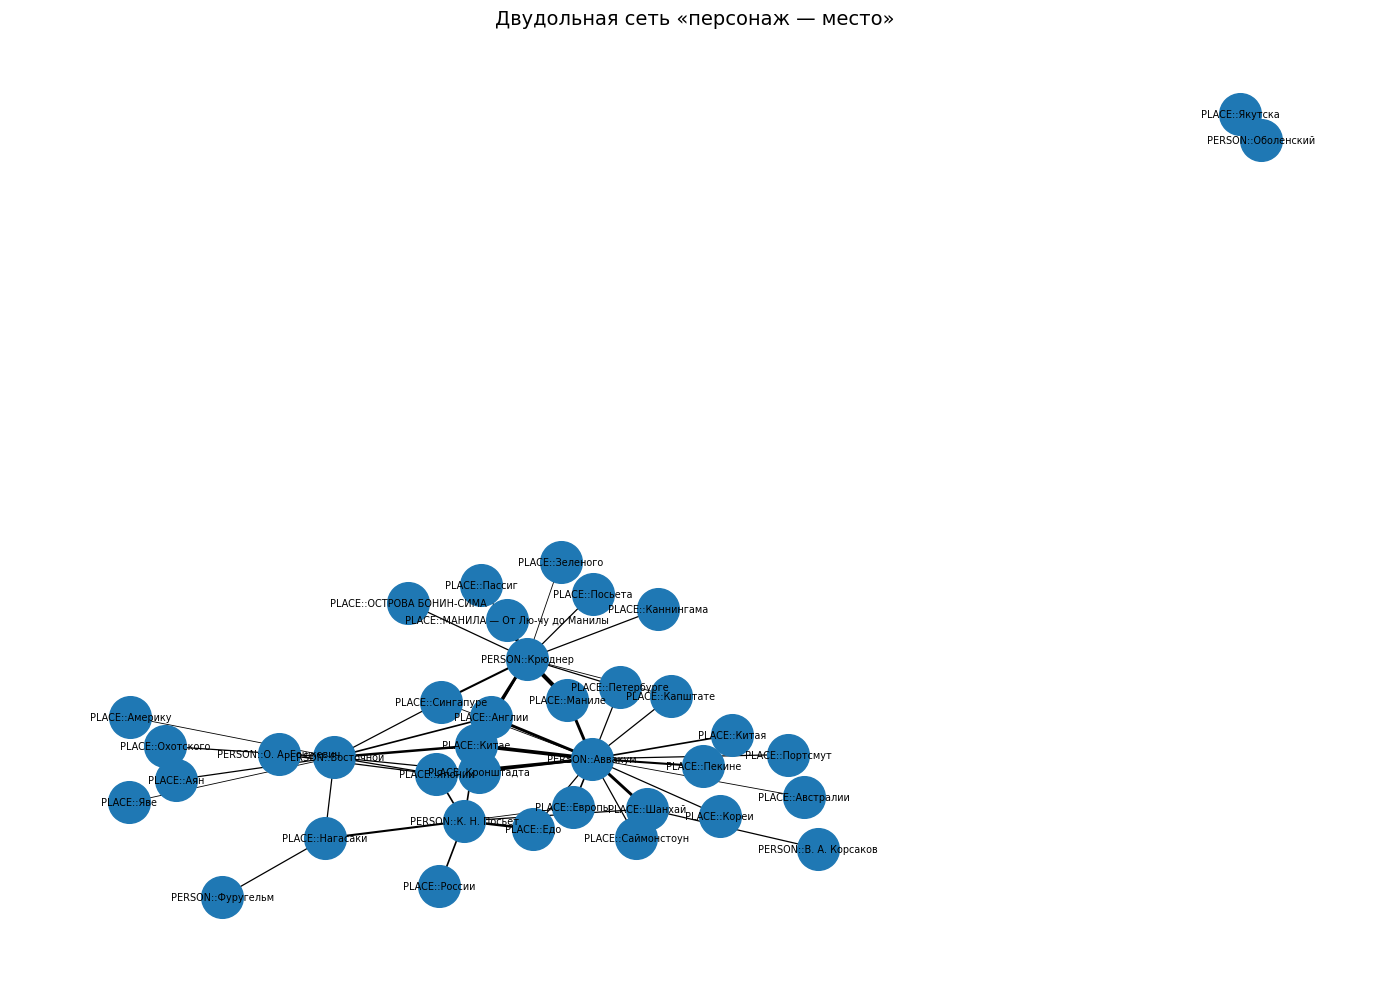

In [8]:

# Сетевой анализ

person_edges = Counter()
for _, r in segments_df.iterrows():
    people = list(r['persons']) if isinstance(r['persons'], list) else []
    for a, b in itertools.combinations(sorted(set(people)), 2):
        person_edges[(a, b)] += 1

person_edges_df = pd.DataFrame([
    {'source': a, 'target': b, 'weight': w}
    for (a, b), w in person_edges.items()
]).sort_values('weight', ascending=False)

place_edges = Counter()
place_seq = [p for p in segments_df['primary_place'].tolist() if isinstance(p, str) and p]
for a, b in zip(place_seq, place_seq[1:]):
    if a != b:
        place_edges[(a, b)] += 1

place_edges_df = pd.DataFrame([
    {'source': a, 'target': b, 'weight': w}
    for (a, b), w in place_edges.items()
]).sort_values('weight', ascending=False)

bip_edges = Counter()
for _, r in segments_df.iterrows():
    people = list(r['persons']) if isinstance(r['persons'], list) else []
    places = list(r['places']) if isinstance(r['places'], list) else []
    for a in people:
        for b in places:
            bip_edges[(a, b)] += 1

bip_edges_df = pd.DataFrame([
    {'person': a, 'place': b, 'weight': w}
    for (a, b), w in bip_edges.items()
]).sort_values('weight', ascending=False)

display(Markdown("## 5. Сетевой анализ"))
display(person_edges_df.head(15))
display(place_edges_df.head(15))
display(bip_edges_df.head(15))

# Сеть персонажей
if not person_edges_df.empty:
    top_person_edges = person_edges_df.head(40)
    Gp = nx.Graph()
    for _, row in top_person_edges.iterrows():
        Gp.add_edge(row['source'], row['target'], weight=row['weight'])
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(Gp, seed=RANDOM_STATE)
    nx.draw_networkx(Gp, pos=pos, with_labels=True, node_size=900, font_size=8, width=[Gp[u][v]['weight'] * 0.5 for u, v in Gp.edges()])
    plt.title("Сеть совместных упоминаний персонажей")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_dir / "person_network.png", dpi=160)
    plt.show()

# Сеть переходов между местами
if not place_edges_df.empty:
    top_place_edges = place_edges_df.head(50)
    Gm = nx.DiGraph()
    for _, row in top_place_edges.iterrows():
        Gm.add_edge(row['source'], row['target'], weight=row['weight'])
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(Gm, seed=RANDOM_STATE)
    nx.draw_networkx(Gm, pos=pos, with_labels=True, node_size=1000, font_size=8, arrows=True,
                     width=[max(0.5, Gm[u][v]['weight'] * 0.4) for u, v in Gm.edges()])
    plt.title("Сеть переходов между местами")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_dir / "place_network.png", dpi=160)
    plt.show()

# Двудольная сеть "персонаж — место"
if not bip_edges_df.empty:
    top_bip = bip_edges_df.head(50)
    Gb = nx.Graph()
    for _, row in top_bip.iterrows():
        person_node = f"PERSON::{row['person']}"
        place_node = f"PLACE::{row['place']}"
        Gb.add_node(person_node, bipartite='person')
        Gb.add_node(place_node, bipartite='place')
        Gb.add_edge(person_node, place_node, weight=row['weight'])
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(Gb, seed=RANDOM_STATE)
    nx.draw_networkx(Gb, pos=pos, with_labels=True, node_size=900, font_size=7,
                     width=[max(0.5, Gb[u][v]['weight'] * 0.3) for u, v in Gb.edges()])
    plt.title("Двудольная сеть «персонаж — место»")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(output_dir / "person_place_bipartite.png", dpi=160)
    plt.show()


## 6. Событийная модель

,episode_id,section_id,event_idx,event_type,date_raw,year,month,place,persons,sentence
0,E001,S01,6,weather,None,NaN,NaN,Кронштадта,None,"Бывало, не заснешь, если в комнату ворвется бо..."
1,E001,S01,10,illness_danger,None,NaN,NaN,Кронштадта,None,"Как уживетесь с новыми людьми?"" – сыпались воп..."
2,E001,S01,11,illness_danger,None,NaN,NaN,Кронштадта,None,"Из этого видно, что у всех, кто не бывал на мо..."
3,E001,S01,17,observation_reflection,None,NaN,NaN,Кронштадта,None,Я изумился: я видался с нею всего раза три в г...
4,E001,S01,20,observation_reflection,None,NaN,NaN,Кронштадта,None,"""Жаль потому, что лишний человек все-таки разв..."
5,E001,S01,26,observation_reflection,None,NaN,NaN,Кронштадта,None,"""Я понял бы ваши слезы, если б это были слезы ..."
6,E001,S01,31,weather,None,NaN,NaN,Кронштадта,None,"Мысль ехать, как хмель, туманила голову, и я б..."
7,E002,S01,5,observation_reflection,None,NaN,NaN,Кронштадта,None,"""Подал бы я, – думалось мне, – доверчиво мудре..."
8,E002,S01,27,movement,None,NaN,NaN,Кронштадта,None,"В другом я – новый аргонавт, в соломенной шляп..."
9,E002,S01,34,weather,None,NaN,NaN,Кронштадта,None,"Морская болезнь, перемены климата, тропический..."


,event_type,count
0,weather,600
1,movement,513
2,observation_reflection,253
3,arrival,214
4,stay,211
5,shipboard_work,194
6,meeting,187
7,illness_danger,87
8,departure,65


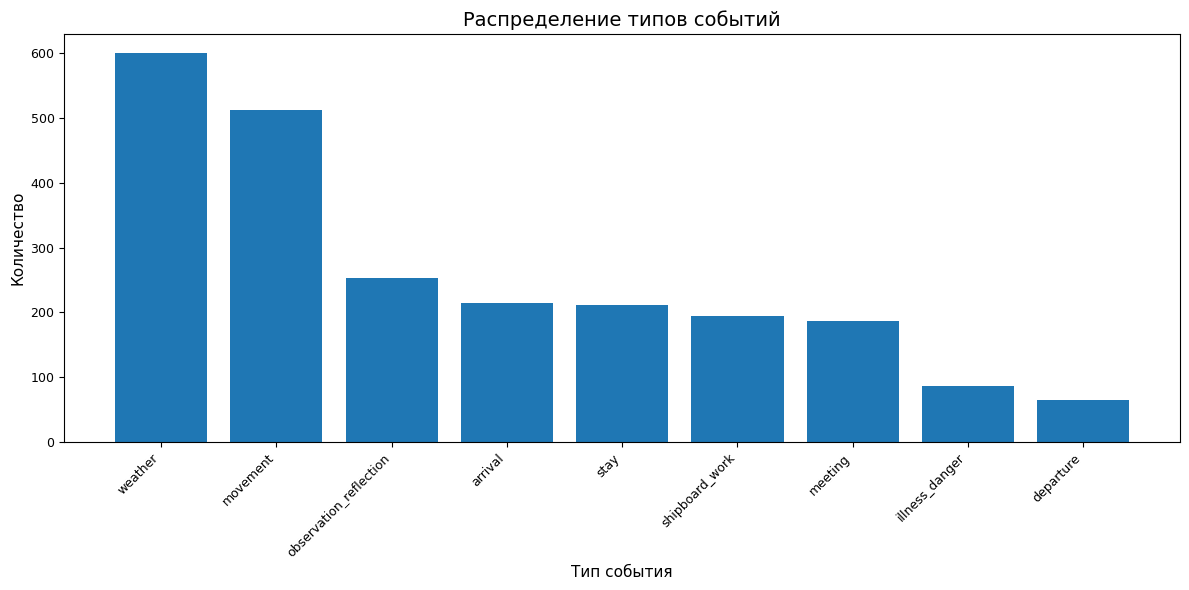

event_type,arrival,departure,illness_danger,meeting,movement,observation_reflection,shipboard_work,stay,weather
section_id,,,,,,,,,
S01,7,5,20,16,30,16,49,5,49
S02,3,1,6,5,27,19,6,9,57
S03,5,0,0,3,18,11,11,7,34
S04,29,15,6,25,70,32,5,54,44
S05,6,0,1,3,13,3,4,7,17
S06,11,6,2,11,34,3,3,13,27
S07,3,1,2,2,6,4,0,2,9
S08,4,1,3,4,4,5,7,4,46
S09,33,0,5,22,50,25,17,17,52


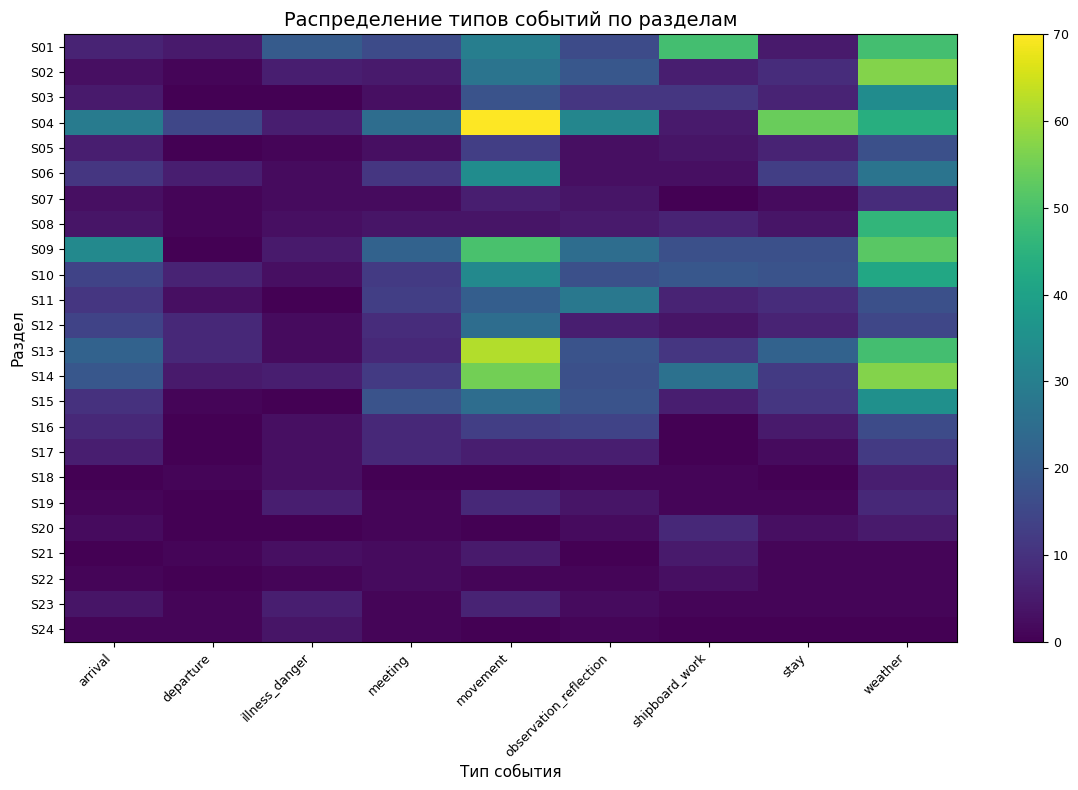

,place_main,event_type,count
239,МАНИЛА — От Лю-чу до Манилы,movement,62
271,Маниле,weather,54
267,Маниле,movement,51
243,МАНИЛА — От Лю-чу до Манилы,weather,48
208,Кронштадта,shipboard_work,48
210,Кронштадта,weather,46
310,ОСТРОВА БОНИН-СИМА,weather,45
187,Китае,movement,29
120,Едо,weather,27
473,Шанхай,weather,26


In [9]:

# Событийная модель

event_rows = []
for _, r in segments_df.iterrows():
    default_persons = r['persons'][:2] if isinstance(r['persons'], list) else []
    default_place = r['primary_place']
    for s_idx, sent in enumerate(split_sentences(r['text'])):
        etype = classify_event(sent)
        if not etype:
            continue
        sent_persons = extract_persons(sent) or default_persons
        sent_places = extract_places(sent, r['episode_title'], r['section_title']) or ([default_place] if default_place else [])
        event_rows.append({
            'episode_id': r['episode_id'],
            'section_id': r['section_id'],
            'event_idx': s_idx,
            'event_type': etype,
            'date_raw': r['date_raw'],
            'year': r['year'],
            'month': r['month'],
            'place': ", ".join(sent_places[:3]) if sent_places else None,
            'persons': ", ".join(sent_persons[:3]) if sent_persons else None,
            'sentence': sent[:400]
        })

events_df = pd.DataFrame(event_rows)

display(Markdown("## 6. Событийная модель"))
display(events_df.head(20))

event_counts_df = events_df['event_type'].value_counts().rename_axis('event_type').reset_index(name='count')
display(event_counts_df)

plt.figure()
plt.bar(event_counts_df['event_type'], event_counts_df['count'])
plt.title("Распределение типов событий")
plt.xlabel("Тип события")
plt.ylabel("Количество")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(output_dir / "event_type_counts.png", dpi=160)
plt.show()

event_section_df = pd.crosstab(events_df['section_id'], events_df['event_type'])
display(event_section_df.head(20))

plt.figure(figsize=(12, 8))
plt.imshow(event_section_df.values, aspect='auto')
plt.title("Распределение типов событий по разделам")
plt.xlabel("Тип события")
plt.ylabel("Раздел")
plt.xticks(range(event_section_df.shape[1]), event_section_df.columns, rotation=45, ha='right')
plt.yticks(range(event_section_df.shape[0]), event_section_df.index)
plt.colorbar()
plt.tight_layout()
plt.savefig(output_dir / "event_by_section_heatmap.png", dpi=160)
plt.show()

top_event_places_df = (
    events_df.dropna(subset=['place'])
    .assign(place_main=lambda d: d['place'].str.split(',').str[0].str.strip())
    .groupby(['place_main', 'event_type'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
display(top_event_places_df.head(20))


In [10]:

# Экспорт результатов

sections_df.to_csv(output_dir / "sections.csv", index=False, encoding="utf-8-sig")
segments_df.to_csv(output_dir / "segments.csv", index=False, encoding="utf-8-sig")
person_lex_df.to_csv(output_dir / "person_lexicon.csv", index=False, encoding="utf-8-sig")
place_lex_df.to_csv(output_dir / "place_lexicon.csv", index=False, encoding="utf-8-sig")
topics_df.to_csv(output_dir / "topics.csv", index=False, encoding="utf-8-sig")
topic_scores_df.to_csv(output_dir / "topic_scores.csv", index=False, encoding="utf-8-sig")
topic_examples_df.to_csv(output_dir / "topic_examples.csv", index=False, encoding="utf-8-sig")
person_edges_df.to_csv(output_dir / "person_edges.csv", index=False, encoding="utf-8-sig")
place_edges_df.to_csv(output_dir / "place_edges.csv", index=False, encoding="utf-8-sig")
bip_edges_df.to_csv(output_dir / "person_place_edges.csv", index=False, encoding="utf-8-sig")
events_df.to_csv(output_dir / "events.csv", index=False, encoding="utf-8-sig")
stats_df.to_csv(output_dir / "text_statistics.csv", index=False, encoding="utf-8-sig")

summary = {
    "docx_path": str(docx_path),
    "output_dir": str(output_dir),
    "n_sections": int(len(sections_df)),
    "n_segments": int(len(segments_df)),
    "n_events": int(len(events_df)),
    "n_persons": int(len(person_lex_df)),
    "n_places": int(len(place_lex_df)),
    "best_k": int(best_k)
}
with open(output_dir / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

display(Markdown("## 7. Экспорт завершен"))
display(summary)


## 7. Экспорт завершен

{'docx_path': '/Users/oksanagoncarova/Downloads/фрегат.docx',
 'output_dir': '/Users/oksanagoncarova/Downloads/фрегат_analysis_outputs',
 'n_sections': 24,
 'n_segments': 290,
 'n_events': 2324,
 'n_persons': 20,
 'n_places': 65,
 'best_k': 4}